# **RUMAKU BUSINESS ANALYSIS**
## **EXECUTIVE SUMMARY**
This analysis investigates the decline in Rumaku's profitability despite changes in sales performance.

### **BUSINESS PROBLEM**
The meeting that prompted this analysis

Head of Retail, early January 2026
"Fourth-quarter sales were up, which is great. However, our profits actually fell, and I can't explain why to the board. Please find out what’s really going on and give me something I can base a decision on by next week."

Five follow-up questions we formulated
1. What was the magnitude of the profit decline, and in exactly which quarter did it occur?
2. Was the cause the product mix, sales channels, or discount policies?
3. Which categories were most affected, and what was their contribution?
4. Did the online channel remain profitable after accounting for shipping costs?
5. What action would most quickly restore margins without killing sales volume?

The analysis follows an end-to-end workflow:
1. Load and integrate transaction and product data
2. Assess and clean data quality issues
3. Investigate ambiguous duplicate transactions
4. Build transaction-level profitability metrics
5. Diagnose the profit decline by quarter, category, channel, and discount
6. Evaluate Online profitability after shipping costs
7. Translate findings into business recommendations

### Tools

- **Python / Pandas:** data loading, cleaning, validation, and diagnostic analysis
- **BigQuery / SQL:** business analysis on the final analysis dataset
- **Power BI:** dashboard and business communication


#**DATA LOADING AND MERGING DATASET**

In [ ]:
#Import, Load, and Merge Data CSV
import pandas as pd
import numpy as np

product = pd.read_csv("/content/drive/MyDrive/rumaku/produk.csv")
transaction = pd.read_csv("/content/drive/MyDrive/rumaku/transaksi.csv")

print("Product shape:", product.shape)
print("Transaction shape:", transaction.shape)

#Merge dataset transaction and product
transaction_product = transaction.merge(product,on="product_id",how="left")
print("Merged dataset shape:", transaction_product.shape)

Product shape: (170, 7)
Transaction shape: (12240, 12)
Merged dataset shape: (12240, 18)


In [ ]:
# Initial inspection
display(transaction_product.head())
transaction_product.info()

,order_id,order_date,customer_id,product_id,store_id,channel,qty,unit_price,discount_pct,shipping_cost,payment_method,order_status,product_name,category,sub_category,brand,list_price,cost_price
0,ORD110836,08/08/2024,C24666,P1148,S99,Online,1,1498000,25.0,388000.0,Tunai,Selesai,Lampu Dinding Gading,Pencahayaan,Lampu Dinding,Ombak Living,1455000,1012000.0
1,ORD103101,2024-10-11,C22154,P1093,S99,online,1,381000,0.0,224000.0,Tunai,Selesai,Vas Keramik Cendana,Dekorasi,Vas Keramik,Kayana,385000,206000.0
2,ORD101208,2025-10-26,C23997,P1125,S99,Online,1,2408000,5.0,66000.0,Kartu Kredit,Selesai,Talenan Kayu Aurora,Peralatan Dapur,Talenan Kayu,Alunan,2400000,1851000.0
3,ORD101965,29/12/2025,C24737,P1138,S99,Online,1,2986000,30.0,186000.0,KARTU KREDIT,Selesai,Lampu Lantai Bromo,Pencahayaan,Lampu Lantai,Sentra Jaya,2980000,2101000.0
4,ORD105617,2025-03-07,C25856,P1083,S10,Toko Fisik,1,7415000,0.0,0.0,Kartu Kredit,Dibatalkan,Nakas Elang,Lemari & Rak,Nakas,Sentra Jaya,7730000,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12240 entries, 0 to 12239
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        12240 non-null  object 
 1   order_date      12240 non-null  object 
 2   customer_id     12240 non-null  object 
 3   product_id      12240 non-null  object 
 4   store_id        11995 non-null  object 
 5   channel         12240 non-null  object 
 6   qty             12240 non-null  int64  
 7   unit_price      12240 non-null  object 
 8   discount_pct    11388 non-null  float64
 9   shipping_cost   11654 non-null  float64
 10  payment_method  11884 non-null  object 
 11  order_status    12240 non-null  object 
 12  product_name    12240 non-null  object 
 13  category        12240 non-null  object 
 14  sub_category    12240 non-null  object 
 15  brand           11802 non-null  object 
 16  list_price      12240 non-null  int64  
 17  cost_price      11264 non-null 

The transaction and product datasets were successfully integrated using product_id, creating a transaction-level dataset enriched with product attributes such as category, brand, and pricing information.

## **Dataset Overview**

The dataset consists of transaction-level sales data combined with product information.

The transaction and product datasets were merged using `product_id`.

The analysis covers transactions from 2024 to 2025 and includes information about:

- Order date and Customer
- Product and Category
- Sales channel and Payment method
- Quantity and Pricing
- Discount
- Product Cost
- Shipping Cost
- Order Status

# **DATA QUALITY ASSESSMENT**

In [ ]:
# Basic data-quality profile
print("Rows:", len(transaction_product))
print("Columns:", len(transaction_product.columns))

print("\nMissing values:")
display(transaction_product.isna().sum().to_frame("missing_values"))

print("\nExact duplicate rows:")
print(transaction_product.duplicated().sum())

Rows: 12240
Columns: 18

Missing values:


,missing_values
order_id,0
order_date,0
customer_id,0
product_id,0
store_id,245
channel,0
qty,0
unit_price,0
discount_pct,852
shipping_cost,586



Exact duplicate rows:
180


## 2.1 Exact Duplicates

Exact duplicates are removed because they would cause transactions, revenue, and profit to be counted more than once.

For transparency, duplicated(keep=False) identifies all rows involved in duplicate pairs, while duplicated() counts the extra rows that will actually be removed.

In [ ]:
exact_duplicate_instances = transaction_product.duplicated(keep=False).sum()
exact_duplicate_rows_to_remove = transaction_product.duplicated().sum()

print("Rows involved in exact duplicate groups:", exact_duplicate_instances)
print("Exact duplicate rows to remove:", exact_duplicate_rows_to_remove)

transaction_product = transaction_product.drop_duplicates().copy()

print("Rows after exact-duplicate removal:", len(transaction_product))
print("Remaining exact duplicates:", transaction_product.duplicated().sum())

Rows involved in exact duplicate groups: 360
Exact duplicate rows to remove: 180
Rows after exact-duplicate removal: 12060
Remaining exact duplicates: 0


# **DATA CLEANING**

The initial data-quality check helps identify missing values and duplicate records that could affect key business metrics such as revenue, order count, and profit. Removing exact duplicates ensures each transaction is counted only once.

## **Standardize Date and Numeric Fields**

In [ ]:
#CHANGE WRONG DATA TYPE
# Convert mixed date formats
raw_date = transaction_product["order_date"].astype(str)
is_iso = raw_date.str.match(r'^\d{4}-\d{2}-\d{2}$')  # cek: ini format Tahun-Bulan-Tanggal, bukan?

# TAMBAHKAN BARIS INI: siapkan kolomnya dulu sebagai tipe datetime kosong
transaction_product["order_date"] = pd.Series(
    pd.NaT, index=transaction_product.index, dtype="datetime64[ns]"
)

# Kelompok 1: yang formatnya Tahun-Bulan-Tanggal -> bilang eksplisit ke pandas
transaction_product.loc[is_iso, "order_date"] = pd.to_datetime(
    raw_date[is_iso], format="%Y-%m-%d"
)

# Kelompok 2: yang formatnya Tanggal-Bulan-Tahun -> bilang eksplisit juga
transaction_product.loc[~is_iso, "order_date"] = pd.to_datetime(
    raw_date[~is_iso], format="%d/%m/%Y"
)

# Convert unit_price to numeric
transaction_product["unit_price"] = pd.to_numeric(
    transaction_product["unit_price"],
    errors="coerce"
)

# Check result
print("Invalid dates:", transaction_product["order_date"].isna().sum())
print("Invalid unit price:", transaction_product["unit_price"].isna().sum())

Invalid dates: 0
Invalid unit price: 1069


The dataset contained inconsistent date formats and non-numeric unit_price values. Standardizing these fields ensures accurate time-series analysis and financial calculations. Converting order_date to datetime enables reliable monthly and quarterly analysis, while converting unit_price to numeric ensures accurate revenue calculations.

## **Standardize Payment Method, Brand, and Channel**

In [ ]:
# CLEANING PAYMENT METHOD
transaction_product["payment_method"] = (
    transaction_product["payment_method"]
    .astype("string")
    .str.strip()
    .str.title()
    .replace({
        "Tunai": "Cash",
        "Ewallet": "E-Wallet",
        "E Wallet": "E-Wallet",
        "Cicilan 0 %": "Cicilan 0%",
        "Cash On Delivery": "COD",
        "Cod" : "COD",
        "Kartu Kredit": "Credit Card",
        "Transfer": "Transfer Bank"
    })
    .fillna("Unknown")
)

# CLEANING BRAND
transaction_product["brand"] = (
    transaction_product["brand"]
    .fillna("Unknown")
)

#CLEANING CHANNEL
transaction_product["channel"] = (
    transaction_product["channel"]
    .astype("string")
    .str.strip()
    .str.title()
    .replace({"Toko Fisik": "Offline"})
    .fillna("Unknown")
)



# Check result
print("Payment methods:")
display(transaction_product["payment_method"].value_counts())

print("\nBrands:")
display(transaction_product["brand"].value_counts(dropna=False))

print("\nChannels:")
display(transaction_product["channel"].value_counts(dropna=False))



Payment methods:


,count
payment_method,
Transfer Bank,3280
E-Wallet,2566
Credit Card,2289
Cicilan 0%,1553
Cash,1154
COD,867
Unknown,351



Brands:


,count
brand,
Rumaku Signature,2371
Sentra Jaya,2341
Ombak Living,2100
Nordika,1831
Kayana,1532
Alunan,1453
Unknown,432



Channels:


,count
channel,
Online,7048
Offline,5012


Different payment method labels were standardized into consistent categories such as Cash, E-Wallet, COD, Credit Card, and Bank Transfer. This ensures each payment method is counted correctly and provides more accurate customer behavior analysis.
Brand and channel fields were standardized to ensure consistent categories and accurate performance analysis. This is especially important when comparing the profitability of Online and physical-store channels.

## **Handle Missing Store ID**

In [ ]:
# Missing store_id cannot be reliably inferred
transaction_product["store_id"] = (
    transaction_product["store_id"]
    .fillna("Unknown")
)

# Check result
print("Missing store_id:", transaction_product["store_id"].isna().sum())



Missing store_id: 0


Missing store_id values were labeled as Unknown because they could not be reliably determined. This avoids incorrect store assignments and ensures more accurate store-level analysis.

## **Handle Discount**

In [ ]:
transaction_product["discount_pct"] = pd.to_numeric(
    transaction_product["discount_pct"],
    errors="coerce"
)

invalid_discount = (
    (transaction_product["discount_pct"] < 0) |
    (transaction_product["discount_pct"] > 100)
)

print("Invalid discount values:", invalid_discount.sum())

# Treat missing/invalid discount as 0 because no valid discount rate is recorded.
transaction_product.loc[invalid_discount, "discount_pct"] = pd.NA
transaction_product["discount_pct"] = (
    transaction_product["discount_pct"].fillna(0)
)

print("Missing discount after cleaning:",
      transaction_product["discount_pct"].isna().sum())

Invalid discount values: 0
Missing discount after cleaning: 0


Missing discount values were treated as zero, while values outside the 0–100% range were considered invalid. Since discounts affect selling prices and profitability, accurate discount data is important for reliable revenue and margin analysis.

## **Handle Shipping Cost**

In [ ]:
# Physical-store transactions do not require shipping.
physical_store = transaction_product["channel"].eq("Offline")

transaction_product.loc[
    physical_store & transaction_product["shipping_cost"].isna(),
    "shipping_cost"
] = 0

# For other channels, use the channel median for missing shipping costs.
transaction_product["shipping_cost"] = (
    transaction_product.groupby("channel")["shipping_cost"]
    .transform(lambda x: x.fillna(x.median()))
)

print("Missing shipping_cost:",
      transaction_product["shipping_cost"].isna().sum())

Missing shipping_cost: 0


Missing shipping costs were handled based on the sales channel. Physical-store transactions were assigned zero, while missing costs in other channels were filled using the channel median. This approach reflects differences in shipping costs between Online and physical stores.

## **Review Shipping Cost Outliers**

In [ ]:
# CHECK SHIPPING COST OUTLIERS

Q1 = transaction_product["shipping_cost"].quantile(0.25)
Q3 = transaction_product["shipping_cost"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

transaction_product["is_shipping_outlier"] = (
    transaction_product["shipping_cost"] > upper_bound
)

print("Potential Shipping outliers:",
      transaction_product["is_shipping_outlier"].sum())

transaction_product.loc[
    transaction_product["is_shipping_outlier"], "shipping_cost"
] = np.nan

transaction_product.loc[
    physical_store & transaction_product["shipping_cost"].isna(), "shipping_cost"
] = 0

transaction_product["shipping_cost"] = (
    transaction_product.groupby("channel")["shipping_cost"]
    .transform(lambda x: x.fillna(x.median()))
)
print("Missing shipping cost:", transaction_product["shipping_cost"].isna().sum())


Potential Shipping outliers: 6
Missing shipping cost: 0


Potentially abnormal shipping costs were identified using the IQR method. These values were not automatically removed because high shipping costs may represent valid transactions. Outlier detection was used for further investigation rather than automatic deletion.

## **Handle Cost Price**

In [ ]:
# Fill missing cost_price with category median
transaction_product["cost_price"] = (
    transaction_product["cost_price"].fillna(
        transaction_product.groupby("category")["cost_price"]
        .transform("median")
    )
)

# Check missing values
print("Missing cost_price:", transaction_product["cost_price"].isna().sum())

# Check invalid values
print("Invalid cost_price:",(transaction_product["cost_price"] <= 0).sum())

Missing cost_price: 0
Invalid cost_price: 0


Missing cost_price values were filled using the median cost within each product category. This preserves the data while reflecting differences in product costs across categories.

## **Handle Unit Price**

In [ ]:
# Fill missing unit_price using list_price and discount
missing_up = transaction_product["unit_price"].isna()
transaction_product.loc[missing_up, "unit_price"] = (
    transaction_product.loc[missing_up, "list_price"]
    * (1 - transaction_product.loc[missing_up, "discount_pct"] / 100)
)
# Check result
print("Missing unit_price:", transaction_product["unit_price"].isna().sum())

Missing unit_price: 0


Missing selling prices were calculated using list price and discount percentage. This keeps incomplete transactions available for revenue and profitability analysis while following the dataset’s pricing logic.

The Formula:

Unit Price = List Price × (1 − Discount %)

### Cleaning Rules Summary

| Field | Treatment | Reason |
|---|---|---|
| `order_date` | Standardize to datetime | Consistent time analysis |
| `payment_method` | Standardize labels | Consistent categories |
| `brand` | Missing → `Unknown` | Cannot reliably infer |
| `channel` | Trim/capitalize labels | Consistent channel grouping |
| `store_id` | Missing → `Unknown` | Cannot reliably infer |
| `discount_pct` | Missing/invalid → 0 | No valid discount recorded |
| `shipping_cost` | Channel-based treatment | Reflect channel business logic |
| `cost_price` | Category median | Preserve records while respecting category cost structure |
| `unit_price` | Recover from list price and discount | Preserve financial calculations |

The cleaning process used business rules based on the meaning of each variable. This shows that data cleaning is not just about removing missing values, but also about understanding the business context.

# **DUPLICATE INVESTIGATION & AMBIGUOUS QUANTITY**

After exact duplicates are removed, a second issue remains: records with the same business key (order_id, product_id, order_date, customer_id) but different quantities.

These are not treated as exact duplicates because the records contain different quantity values. They require investigation before any record is removed.

In [ ]:
business_key = [
    "order_id",
    "product_id",
    "order_date",
    "customer_id"
]

business_key_duplicates = transaction_product[
    transaction_product.duplicated(
        subset=business_key,
        keep=False
    )
].sort_values(["order_id", "qty"])

print("Business-key duplicate rows:", len(business_key_duplicates))
display(
    business_key_duplicates[
        [
            "order_id", "order_date", "customer_id", "product_id",
            "product_name", "qty", "unit_price", "discount_pct",
            "shipping_cost", "order_status", "cost_price"
        ]
    ].head(20)
)

Business-key duplicate rows: 120


,order_id,order_date,customer_id,product_id,product_name,qty,unit_price,discount_pct,shipping_cost,order_status,cost_price
10411,ORD100089,2024-04-22,C26772,P1046,Springbed 160x200 Cendana,1,5225000.0,10.0,240000.0,Selesai,3439000.0
9881,ORD100089,2024-04-22,C26772,P1046,Springbed 160x200 Cendana,2,5225000.0,10.0,240000.0,Selesai,3439000.0
3382,ORD100535,2024-09-10,C24692,P1006,Sofa 3 Seater Elang,1,3748000.0,30.0,392000.0,Selesai,2268000.0
1600,ORD100535,2024-09-10,C24692,P1006,Sofa 3 Seater Elang,2,3748000.0,30.0,392000.0,Selesai,2268000.0
4511,ORD100675,2025-02-22,C20748,P1040,Meja TV Damar,1,4598000.0,5.0,208000.0,Selesai,3011000.0
5383,ORD100675,2025-02-22,C20748,P1040,Meja TV Damar,2,4598000.0,5.0,208000.0,Selesai,3011000.0
9874,ORD100767,2025-12-21,C23242,P1161,Gorden Blackout Damar,1,1466000.0,20.0,0.0,Selesai,712000.0
5759,ORD100767,2025-12-21,C23242,P1161,Gorden Blackout Damar,2,1466000.0,20.0,0.0,Selesai,712000.0
1660,ORD100799,2025-12-02,C25141,P1088,Cermin Dinding Fajar,1,140000.0,30.0,365000.0,Selesai,109000.0
9012,ORD100799,2025-12-02,C25141,P1088,Cermin Dinding Fajar,2,140000.0,30.0,365000.0,Selesai,109000.0


In [ ]:
qty_pattern = (
    business_key_duplicates
    .groupby(business_key)["qty"]
    .agg(["min", "max", "count"])
    .reset_index()
)

qty_pattern["qty_difference"] = (
    qty_pattern["max"] - qty_pattern["min"]
)

print("Duplicate groups:", len(qty_pattern))
print(
    "Groups where qty difference = 1:",
    (qty_pattern["qty_difference"] == 1).sum()
)
print(
    "Groups where qty difference != 1:",
    (qty_pattern["qty_difference"] != 1).sum()
)

Duplicate groups: 60
Groups where qty difference = 1: 60
Groups where qty difference != 1: 0


In [ ]:
# Verify that all other transaction attributes are identical
check_columns = [
    "order_id", "order_date", "customer_id", "product_id",
    "store_id", "channel", "unit_price", "discount_pct",
    "shipping_cost", "payment_method", "order_status",
    "product_name", "category", "sub_category", "brand",
    "list_price", "cost_price"
]

duplicate_without_qty = (
    business_key_duplicates
    .groupby(check_columns, dropna=False)
    .size()
    .reset_index(name="count")
)

print(
    "Duplicate groups when excluding qty:",
    len(duplicate_without_qty)
)
print(
    "Rows involved:",
    duplicate_without_qty["count"].sum()
)

Duplicate groups when excluding qty: 60
Rows involved: 120


In [ ]:
# Distribution of ambiguous records
duplicate_summary = (
    business_key_duplicates
    .groupby("order_status")
    .size()
    .reset_index(name="rows")
)

duplicate_by_channel = (
    business_key_duplicates
    .groupby("channel")
    .size()
    .reset_index(name="rows")
    .sort_values("rows", ascending=False)
)

print("By order status:")
display(duplicate_summary)

print("By channel:")
display(duplicate_by_channel)

By order status:


,order_status,rows
0,Dibatalkan,2
1,Retur,8
2,Selesai,110


By channel:


,channel,rows
1,Online,68
0,Offline,52


### Duplicate Investigation Result

The investigation shows:
- **60 duplicate groups**
- **120 rows involved**
- Every group has a **quantity difference of exactly 1**
- All other checked attributes are identical

Because the correct quantity cannot be determined from the available fields, the records are **flagged rather than arbitrarily overwritten or deleted**.

In [ ]:
# Flag ambiguous transaction groups without changing row count
ambiguous_key_set = set(
    map(
        tuple,
        business_key_duplicates[business_key]
        .drop_duplicates()
        .values
    )
)

transaction_product["is_ambiguous_qty"] = (
    transaction_product[business_key]
    .apply(tuple, axis=1)
    .isin(ambiguous_key_set)
)

print("Total rows:", len(transaction_product))
display(
    transaction_product["is_ambiguous_qty"]
    .value_counts()
)

Total rows: 12060


,count
is_ambiguous_qty,
False,11940
True,120


## **Sensitivity / Materiality Assessment**

In [ ]:
# Build one row per ambiguous group
ambiguous = (
    business_key_duplicates
    .groupby(business_key, as_index=False)
    .agg(
        qty_min=("qty", "min"),
        qty_max=("qty", "max"),
        unit_price=("unit_price", "first"),
        cost_price=("cost_price", "first"),
        shipping_cost=("shipping_cost", "first")
    )
)

# unit_price is treated as the transaction selling price.
# Do not apply discount_pct again here.
ambiguous["revenue_min"] = (
    ambiguous["qty_min"] * ambiguous["unit_price"]
)
ambiguous["revenue_max"] = (
    ambiguous["qty_max"] * ambiguous["unit_price"]
)

ambiguous["profit_min"] = (
    ambiguous["revenue_min"]
    - ambiguous["qty_min"] * ambiguous["cost_price"]
    - ambiguous["shipping_cost"]
)

ambiguous["profit_max"] = (
    ambiguous["revenue_max"]
    - ambiguous["qty_max"] * ambiguous["cost_price"]
    - ambiguous["shipping_cost"]
)

potential_revenue_range = (
    ambiguous["revenue_max"].sum()
    - ambiguous["revenue_min"].sum()
)

potential_profit_range = (
    ambiguous["profit_max"].sum()
    - ambiguous["profit_min"].sum()
)

print("Ambiguous groups:", len(ambiguous))
print(f"Potential revenue range: Rp {potential_revenue_range:,.0f}")
print(f"Potential profit range: Rp {potential_profit_range:,.0f}")

Ambiguous groups: 60
Potential revenue range: Rp 1,086,419,000
Potential profit range: Rp 989,596,000


**Interpretation:** the ambiguity is material enough to disclose, but it can be handled transparently by excluding the flagged rows from the base-case analysis and retaining them in the cleaned dataset for auditability.

# **DATA VALIDATION & ANALYSIS DATASET**
After data cleaning, the dataset requires a final validation step to ensure that duplicate records, missing values, and incorrect data types have been appropriately addressed before calculating financial metrics.

In [ ]:
# Base-case dataset: exclude only ambiguous quantity records.
transaction_analysis = transaction_product[
    ~transaction_product["is_ambiguous_qty"]
].copy()

print("Full cleaned rows:", len(transaction_product))
print("Analysis rows:", len(transaction_analysis))
print(
    "Ambiguous rows excluded:",
    transaction_product["is_ambiguous_qty"].sum()
)

print("\nAnalysis missing values:")
display(transaction_analysis.isna().sum().to_frame("missing_values"))

print("\nAnalysis exact duplicates:",
      transaction_analysis.duplicated().sum())

print("\nData types:")
transaction_analysis.info()

Full cleaned rows: 12060
Analysis rows: 11940
Ambiguous rows excluded: 120

Analysis missing values:


,missing_values
order_id,0
order_date,0
customer_id,0
product_id,0
store_id,0
channel,0
qty,0
unit_price,0
discount_pct,0
shipping_cost,0



Analysis exact duplicates: 0

Data types:
<class 'pandas.core.frame.DataFrame'>
Index: 11940 entries, 0 to 12239
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   order_id             11940 non-null  object        
 1   order_date           11940 non-null  datetime64[ns]
 2   customer_id          11940 non-null  object        
 3   product_id           11940 non-null  object        
 4   store_id             11940 non-null  object        
 5   channel              11940 non-null  string        
 6   qty                  11940 non-null  int64         
 7   unit_price           11940 non-null  float64       
 8   discount_pct         11940 non-null  float64       
 9   shipping_cost        11940 non-null  float64       
 10  payment_method       11940 non-null  string        
 11  order_status         11940 non-null  object        
 12  product_name         11940 non-null  object       

In [ ]:
print("\nOrder status distribution (seluruh analysis dataset):")
display(transaction_analysis["order_status"].value_counts(dropna=False))

non_completed = transaction_analysis[
    transaction_analysis["order_status"] != "Selesai"
].copy()
non_completed["revenue"] = non_completed["qty"] * non_completed["unit_price"]
non_completed["net_profit"] = (
    non_completed["revenue"]
    - non_completed["qty"] * non_completed["cost_price"]
    - non_completed["shipping_cost"]
)
print(f"\nRows non-completed: {len(non_completed)} "
      f"({len(non_completed)/len(transaction_analysis)*100:.2f}%)")
print(f"Revenue yang salah masuk hitungan  : Rp {non_completed['revenue'].sum():,.0f}")
print(f"Net profit yang salah masuk hitungan: Rp {non_completed['net_profit'].sum():,.0f}")

transaction_analysis["is_completed_order"] = (
    transaction_analysis["order_status"].eq("Selesai")
)
transaction_sales = transaction_analysis[
    transaction_analysis["is_completed_order"]
].copy()

print("\nFinal transaction_sales rows:", len(transaction_sales))


Order status distribution (seluruh analysis dataset):


,count
order_status,
Selesai,10933
Dibatalkan,660
Retur,347



Rows non-completed: 1007 (8.43%)
Revenue yang salah masuk hitungan  : Rp 10,638,628,252
Net profit yang salah masuk hitungan: Rp 4,311,126,252

Final transaction_sales rows: 10933


### Final Data Treatment

- The **full cleaned dataset** retains all 12,060 rows and includes the `is_ambiguous_qty` flag.
- The **base-case analysis dataset** contains 11,940 rows.
- The 120 ambiguous rows are excluded from base-case profitability calculations because their correct quantity cannot be verified.
- No ambiguous record is silently overwritten.

# **CALCULATE BUSINESS METRICS**
The next stage converts cleaned transaction data into business metrics to measure financial performance. This shifts the analysis from “Is the data correct?” to “What is happening to the business?”

In [ ]:
transaction_sales["revenue"] = (
    transaction_sales["qty"] *
    transaction_sales["unit_price"])

transaction_sales["total_cost"] = (
    transaction_sales["qty"] *
    transaction_sales["cost_price"])

transaction_sales["gross_profit"] = (
    transaction_sales["revenue"] -
    transaction_sales["total_cost"])

transaction_sales["net_profit"] = (
    transaction_sales["gross_profit"] -
    transaction_sales["shipping_cost"])

transaction_sales["quarter"] = (
    transaction_sales["order_date"]
    .dt.to_period("Q")
    .astype(str))

transaction_sales["quarter"].value_counts().sort_index()


,count
quarter,
2024Q1,1082
2024Q2,1283
2024Q3,1028
2024Q4,1398
2025Q1,1475
2025Q2,1593
2025Q3,1263
2025Q4,1811


The analysis separates revenue, product costs, shipping costs, gross profit, and net profit to identify the main causes of profitability changes. A decline in net profit may result from lower revenue, higher costs, or lower product margins.

## **Quarterly Performance**

In [ ]:
#Quarter analysis
quarterly = (
    transaction_sales.groupby("quarter")
    .agg(revenue=("revenue", "sum"),net_profit=("net_profit", "sum"))
    .reset_index()
)

quarterly["profit_margin"] = (
    quarterly["net_profit"] /
    quarterly["revenue"] * 100
)

quarterly["profit_change"] = (
    quarterly["net_profit"].pct_change() * 100
)

display(quarterly)

,quarter,revenue,net_profit,profit_margin,profit_change
0,2024Q1,6.434633e+09,2.099136e+09,32.622467,NaN
1,2024Q2,6.557338e+09,2.113285e+09,32.227788,0.674039
2,2024Q3,5.503120e+09,2.370312e+09,43.072148,12.162439
3,2024Q4,6.180556e+09,1.904868e+09,30.820340,-19.636381
4,2025Q1,9.295288e+09,3.193960e+09,34.361064,67.673503
5,2025Q2,1.460922e+10,5.647917e+09,38.659937,76.831181
6,2025Q3,5.695672e+09,1.890390e+09,33.189935,-66.529433
7,2025Q4,1.167405e+10,3.728539e+09,31.938685,97.236496


Quarterly aggregation shows how revenue and profitability evolve over time and provides the foundation for identifying when the business performance deteriorated.

Q3 2025 marked the sharpest profitability deterioration, with net profit falling 66.53% QoQ from Rp5.65B to Rp1.89B. Revenue also fell sharply to Rp5.70B (down 61.01% from Q2), and profit margin declined from 38.66% to 33.19%. This indicates the decline was driven by both a large drop in sales volume and margin compression, not margin alone.


In [ ]:
# Identify the quarter with the largest QoQ net-profit decline
declines = quarterly.dropna(subset=["profit_change"])

largest_decline = declines.loc[
    declines["profit_change"].idxmin()
]

print(
    f"Largest QoQ net-profit decline: "
    f"{largest_decline['quarter']} "
    f"({largest_decline['profit_change']:.2f}%)"
)

Largest QoQ net-profit decline: 2025Q3 (-66.53%)


The decline was accompanied by a substantial drop in revenue (-61.01% QoQ), not just margin compression. Net profit fell by 66.53% QoQ, accompanied by a decline in profit margin from 38.66% to 33.19%. Both volume and margin need to be investigated.

## **KPI OVERVIEW**
The KPI overview provides a high-level view of business performance. Revenue measures business scale, net profit shows total profitability, profit margin measures profitability efficiency, and total orders reflects sales activity.

In [ ]:
# KPI Overview

total_revenue = transaction_sales["revenue"].sum()
total_net_profit = transaction_sales["net_profit"].sum()
profit_margin = total_net_profit / total_revenue * 100
total_orders = transaction_sales["order_id"].nunique()

print(f"Total Revenue    : Rp {total_revenue:,.0f}")
print(f"Total Net Profit : Rp {total_net_profit:,.0f}")
print(f"Profit Margin    : {profit_margin:.2f}%")
print(f"Total Orders     : {total_orders:,}")

Total Revenue    : Rp 65,949,882,252
Total Net Profit : Rp 22,948,406,252
Profit Margin    : 34.80%
Total Orders     : 10,933


The overall business performance is summarized through total revenue, net profit, profit margin, and total orders.

# **BUSINESS ANALYSIS**

## **1. What was the magnitude of the profit decline, and exactly which quarter did it occur?**

In [ ]:
quarterly["profit_change"] = (
    quarterly["net_profit"].pct_change() * 100
)

display(quarterly)

,quarter,revenue,net_profit,profit_margin,profit_change
0,2024Q1,6.434633e+09,2.099136e+09,32.622467,NaN
1,2024Q2,6.557338e+09,2.113285e+09,32.227788,0.674039
2,2024Q3,5.503120e+09,2.370312e+09,43.072148,12.162439
3,2024Q4,6.180556e+09,1.904868e+09,30.820340,-19.636381
4,2025Q1,9.295288e+09,3.193960e+09,34.361064,67.673503
5,2025Q2,1.460922e+10,5.647917e+09,38.659937,76.831181
6,2025Q3,5.695672e+09,1.890390e+09,33.189935,-66.529433
7,2025Q4,1.167405e+10,3.728539e+09,31.938685,97.236496


Q3 2025 recorded the largest quarter-over-quarter decline in net profit, falling by 66.53% compared with Q2 2025. This represents an approximately Rp3.76 billion decrease in net profit, from Rp5.65 billion in Q2 to Rp1.89 billion in Q3.

## **2. Is it driven by the product mix, sales channels, or discount policies?**

In [ ]:
#Analysis by product category
category_analysis = (
    transaction_sales
    .groupby(["quarter", "category"])
    .agg(
        revenue=("revenue", "sum"),
        net_profit=("net_profit", "sum")
    )
    .reset_index()
)

#Analysis by channel
channel_analysis = (
    transaction_sales
    .groupby(["quarter", "channel"])
    .agg(
        revenue=("revenue", "sum"),
        net_profit=("net_profit", "sum"),
        shipping_cost=("shipping_cost", "sum")
    )
    .reset_index()
)

#Analysis by discount
discount_analysis = (
    transaction_sales
    .groupby(["quarter", "discount_pct"])
    .agg(
        revenue=("revenue", "sum"),
        net_profit=("net_profit", "sum")
    )
    .reset_index()
)

print("\nCategory analysis:")
display(category_analysis)

print("\nChannel analysis:")
display(channel_analysis)

print("\nDiscount analysis:")
display(discount_analysis)


Category analysis:


,quarter,category,revenue,net_profit
0,2024Q1,Dekorasi,9.769450e+07,29134500.0
1,2024Q1,Kasur & Springbed,1.203976e+09,415468500.0
2,2024Q1,Lemari & Rak,6.449345e+08,187759500.0
3,2024Q1,Meja,8.301678e+08,231668750.0
4,2024Q1,Pencahayaan,3.187698e+08,60491750.0
...,...,...,...,...
59,2025Q4,Meja,1.159100e+09,309199500.0
60,2025Q4,Pencahayaan,5.675555e+08,105453501.0
61,2025Q4,Peralatan Dapur,3.916875e+08,67096500.0
62,2025Q4,Sofa & Kursi,2.214495e+09,679174250.0



Channel analysis:


,quarter,channel,revenue,net_profit,shipping_cost
0,2024Q1,Offline,2.070702e+09,7.193770e+08,0.0
1,2024Q1,Online,4.363931e+09,1.379759e+09,187228000.0
2,2024Q2,Offline,2.510334e+09,9.066308e+08,0.0
3,2024Q2,Online,4.047004e+09,1.206654e+09,203018000.0
4,2024Q3,Offline,2.864563e+09,1.614975e+09,0.0
5,2024Q3,Online,2.638557e+09,7.553370e+08,163705000.0
6,2024Q4,Offline,2.562218e+09,8.939920e+08,0.0
7,2024Q4,Online,3.618338e+09,1.010876e+09,224866000.0
8,2025Q1,Offline,2.579302e+09,9.467790e+08,0.0
9,2025Q1,Online,6.715986e+09,2.247181e+09,237757000.0



Discount analysis:


,quarter,discount_pct,revenue,net_profit
0,2024Q1,0.0,1.610185e+09,526129000.0
1,2024Q1,5.0,8.063648e+08,254883750.0
2,2024Q1,10.0,8.515665e+08,255226500.0
3,2024Q1,15.0,5.934882e+08,145991250.0
4,2024Q1,20.0,2.169105e+09,816845000.0
...,...,...,...,...
56,2025Q4,25.0,1.188804e+09,352391250.0
57,2025Q4,30.0,9.105505e+08,223305500.0
58,2025Q4,35.0,7.860065e+08,235218500.0
59,2025Q4,40.0,2.588130e+08,74463000.0


Category-level analysis shows which product categories contributed to the overall profit decline. This helps determine whether the decline affected all categories or only specific ones.

Channel-level analysis compares revenue, net profit, and shipping costs across sales channels. This helps identify whether profit declines are linked to a specific channel, especially whether Online sales remain profitable after shipping costs.

Discount-level analysis examines whether higher discounts affect revenue and profitability. Higher discounts do not always reduce profit; the key is whether increased sales volume can offset the lower unit margin.

### **COMPARE Q2 2025 VS Q3 2025**

In [ ]:
# Compare product category: 2025Q2 vs 2025Q3
category_q2_q3 = (
    transaction_sales[
        transaction_sales["quarter"].isin(["2025Q2", "2025Q3"])
    ]
    .groupby(["quarter", "category"])
    .agg(
        revenue=("revenue", "sum"),
        net_profit=("net_profit", "sum")
    )
    .reset_index()
)

display(category_q2_q3)

# Compare sales channel: 2025Q2 vs 2025Q3

channel_q2_q3 = (
    transaction_sales[
        transaction_sales["quarter"].isin(["2025Q2", "2025Q3"])
    ]
    .groupby(["quarter", "channel"])
    .agg(
        revenue=("revenue", "sum"),
        net_profit=("net_profit", "sum"),
        shipping_cost=("shipping_cost", "sum")
    )
    .reset_index()
)

display(channel_q2_q3)

# Compare discount level: 2025Q2 vs 2025Q3

discount_q2_q3 = (
    transaction_sales[
        transaction_sales["quarter"].isin(["2025Q2", "2025Q3"])
    ]
    .groupby("quarter")
    .agg(
        avg_discount=("discount_pct", "mean"),
        revenue=("revenue", "sum"),
        net_profit=("net_profit", "sum")
    )
    .reset_index()
)

display(discount_q2_q3)

,quarter,category,revenue,net_profit
0,2025Q2,Dekorasi,1.675625e+08,5.957050e+07
1,2025Q2,Kasur & Springbed,6.436405e+09,2.405571e+09
2,2025Q2,Lemari & Rak,3.120086e+09,1.092962e+09
3,2025Q2,Meja,1.052042e+09,2.931645e+08
4,2025Q2,Pencahayaan,1.320216e+09,1.018364e+09
5,2025Q2,Peralatan Dapur,3.197150e+08,4.804300e+07
6,2025Q2,Sofa & Kursi,2.009234e+09,6.758065e+08
7,2025Q2,Tekstil,1.839628e+08,5.443575e+07
8,2025Q3,Dekorasi,1.259810e+08,4.004800e+07
9,2025Q3,Kasur & Springbed,1.494018e+09,5.976435e+08


,quarter,channel,revenue,net_profit,shipping_cost
0,2025Q2,Offline,7.600144e+09,2.839195e+09,0.0
1,2025Q2,Online,7.009080e+09,2.808722e+09,251168000.0
2,2025Q3,Offline,2.342562e+09,8.702362e+08,0.0
3,2025Q3,Online,3.353110e+09,1.020154e+09,213227000.0


,quarter,avg_discount,revenue,net_profit
0,2025Q2,8.047709,1.460922e+10,5.647917e+09
1,2025Q3,8.788599,5.695672e+09,1.890390e+09


The Q2-to-Q3 comparison focuses on the period with the largest profit decline. It helps identify changes in product mix, sales channels, and discount levels that may have contributed to the decline.

In [ ]:
# Compare profit margin by channel: 2025Q2 vs 2025Q3

channel_margin = (
    transaction_sales[
        transaction_sales["quarter"].isin(["2025Q2", "2025Q3"])
    ]
    .groupby(["quarter", "channel"])
    .agg(
        revenue=("revenue", "sum"),
        net_profit=("net_profit", "sum")
    )
    .reset_index()
)

channel_margin["profit_margin"] = (
    channel_margin["net_profit"] /
    channel_margin["revenue"] * 100
)

display(channel_margin)


# Compare profit margin by category: 2025Q2 vs 2025Q3

category_margin = (
    transaction_sales[
        transaction_sales["quarter"].isin(["2025Q2", "2025Q3"])
    ]
    .groupby(["quarter", "category"])
    .agg(
        revenue=("revenue", "sum"),
        net_profit=("net_profit", "sum")
    )
    .reset_index()
)

category_margin["profit_margin"] = (
    category_margin["net_profit"] /
    category_margin["revenue"] * 100
)

display(category_margin)

,quarter,channel,revenue,net_profit,profit_margin
0,2025Q2,Offline,7.600144e+09,2.839195e+09,37.357123
1,2025Q2,Online,7.009080e+09,2.808722e+09,40.072616
2,2025Q3,Offline,2.342562e+09,8.702362e+08,37.148906
3,2025Q3,Online,3.353110e+09,1.020154e+09,30.424103


,quarter,category,revenue,net_profit,profit_margin
0,2025Q2,Dekorasi,1.675625e+08,5.957050e+07,35.551212
1,2025Q2,Kasur & Springbed,6.436405e+09,2.405571e+09,37.374448
2,2025Q2,Lemari & Rak,3.120086e+09,1.092962e+09,35.029846
3,2025Q2,Meja,1.052042e+09,2.931645e+08,27.866249
4,2025Q2,Pencahayaan,1.320216e+09,1.018364e+09,77.136170
5,2025Q2,Peralatan Dapur,3.197150e+08,4.804300e+07,15.026821
6,2025Q2,Sofa & Kursi,2.009234e+09,6.758065e+08,33.635024
7,2025Q2,Tekstil,1.839628e+08,5.443575e+07,29.590637
8,2025Q3,Dekorasi,1.259810e+08,4.004800e+07,31.788921
9,2025Q3,Kasur & Springbed,1.494018e+09,5.976435e+08,40.002416


Profit margin provides a better comparison across channels and categories because it accounts for differences in sales volume. It shows which categories and channels generate profit most efficiently.

In [ ]:
# Compare Q2 vs Q3 overall performance

q2_q3 = (
    transaction_sales[
        transaction_sales["quarter"].isin(["2025Q2", "2025Q3"])
    ]
    .groupby("quarter")
    .agg(
        revenue=("revenue", "sum"),
        gross_profit=("gross_profit", "sum"),
        shipping_cost=("shipping_cost", "sum"),
        net_profit=("net_profit", "sum")
    )
    .reset_index()
)

q2_q3["profit_margin"] = (
    q2_q3["net_profit"] /
    q2_q3["revenue"] * 100
)

display(q2_q3)

,quarter,revenue,gross_profit,shipping_cost,net_profit,profit_margin
0,2025Q2,1.460922e+10,5.899085e+09,251168000.0,5.647917e+09,38.659937
1,2025Q3,5.695672e+09,2.103617e+09,213227000.0,1.890390e+09,33.189935


The Q2-to-Q3 comparison shows a decline in revenue, gross profit, net profit, and profit margin. This indicates that Q3 faced not only lower sales but also weaker profitability.

## **3. Which categories were most affected, and what is their contribution?**

In [ ]:
category_q2_q3 = (
    transaction_sales[
        transaction_sales["quarter"].isin(["2025Q2", "2025Q3"])
    ]
    .groupby(["quarter", "category"])
    .agg(
        revenue=("revenue", "sum"),
        net_profit=("net_profit", "sum")
    )
    .reset_index()
)

category_pivot = category_q2_q3.pivot(
    index="category",
    columns="quarter",
    values="net_profit"
).reset_index()

for col in ["2025Q2", "2025Q3"]:
    if col not in category_pivot.columns:
        category_pivot[col] = 0

category_pivot["profit_change"] = (
    category_pivot["2025Q3"] -
    category_pivot["2025Q2"]
)

total_decline = (
    category_pivot.loc[
        category_pivot["profit_change"] < 0,
        "profit_change"
    ].sum()
)

category_pivot["contribution_pct"] = (
    category_pivot["profit_change"]
    / total_decline * 100
)

category_pivot = category_pivot.sort_values("profit_change")
display(category_pivot)

quarter,category,2025Q2,2025Q3,profit_change,contribution_pct
1,Kasur & Springbed,2.405571e+09,597643500.0,-1.807927e+09,48.114817
4,Pencahayaan,1.018364e+09,67701250.0,-9.506630e+08,25.300231
2,Lemari & Rak,1.092962e+09,371292500.0,-7.216690e+08,19.205956
6,Sofa & Kursi,6.758065e+08,470204250.0,-2.056022e+08,5.471744
3,Meja,2.931645e+08,248641750.0,-4.452275e+07,1.184895
0,Dekorasi,5.957050e+07,40048000.0,-1.952250e+07,0.519557
7,Tekstil,5.443575e+07,48553750.0,-5.882000e+06,0.156539
5,Peralatan Dapur,4.804300e+07,46304750.0,-1.738250e+06,0.046260


The profit decline was highly concentrated in three categories:

Kasur & Springbed: approximately -Rp1.81B, contributing 48.11% of the total category-level decline.
Pencahayaan: approximately -Rp0.95B, contributing 25.30%.
Lemari & Rak: approximately -Rp0.72B, contributing 19.21%.

Together, these three categories accounted for approximately 92.62% of the total category-level profit decline. This indicates that the profitability deterioration was highly concentrated rather than evenly distributed across the product portfolio. Management can therefore prioritize these three categories when investigating the drivers of the Q3 2025 margin deterioration.

## **4. Does the online channel remain profitable after accounting for shipping costs?**

In [ ]:
online_analysis = (
    transaction_sales[
        transaction_sales["channel"] == "Online"
    ]
    .groupby("quarter")
    .agg(
        revenue=("revenue", "sum"),
        gross_profit=("gross_profit", "sum"),
        shipping_cost=("shipping_cost", "sum"),
        net_profit=("net_profit", "sum")
    )
    .reset_index()
)

online_analysis["profit_margin"] = (
    online_analysis["net_profit"] /
    online_analysis["revenue"] * 100
)

display(online_analysis)

,quarter,revenue,gross_profit,shipping_cost,net_profit,profit_margin
0,2024Q1,4.363931e+09,1.566987e+09,187228000.0,1.379759e+09,31.617342
1,2024Q2,4.047004e+09,1.409672e+09,203018000.0,1.206654e+09,29.815987
2,2024Q3,2.638557e+09,9.190420e+08,163705000.0,7.553370e+08,28.626897
3,2024Q4,3.618338e+09,1.235742e+09,224866000.0,1.010876e+09,27.937588
4,2025Q1,6.715986e+09,2.484938e+09,237757000.0,2.247181e+09,33.460177
5,2025Q2,7.009080e+09,3.059890e+09,251168000.0,2.808722e+09,40.072616
6,2025Q3,3.353110e+09,1.233380e+09,213227000.0,1.020154e+09,30.424103
7,2025Q4,4.851373e+09,1.660089e+09,297832000.0,1.362257e+09,28.079828


The Online channel remained profitable after shipping costs, but its profitability deteriorated significantly.

1. Q2 2025 - Profit margin = 40.07%
2. Q3 2025 - Profit margin = 30.42%
3. Decline: 9.65 percentage points

Online sales should not necessarily be reduced because the channel remains profitable. Instead, management should investigate shipping efficiency, product mix, pricing, and discount levels to recover the lost margin.

## **5. What actions would most quickly restore margins without killing sales volume?**


**Recommendations**
1. Prioritize Kasur & Springbed, Pencahayaan, and Lemari & Rak.
These three categories contributed approximately 92.62% of the total net profit decline from Q2 to Q3 2025. Management should review pricing, product mix, and promotional strategy for these categories first.

2. Review Online channel profitability.
Online remained profitable after shipping costs, but its profit margin declined from 40.07% in Q2 to 30.42% in Q3. Management should investigate the drivers of the Online margin decline, with particular attention to shipping costs, pricing, and transaction mix.

3. Use targeted discounts instead of broad discounting.
Average discount increased from 8.05% to 8.79% (+0.74pp) during the same period that profit margin declined by 5.47 percentage point. Management should therefore evaluate whether discounting is generating sufficient incremental sales to justify the margin reduction.

4. Protect sales volume while improving margin.
Since the major issue in Q3 was the sharp decline in revenue, aggressive price increases or removing discounts entirely could further reduce volume. Margin recovery should therefore focus on targeted pricing, product mix optimization, and shipping efficiency.




**Conclusion**

Net profit declined by 66.53% from Q2 to Q3 2025, primarily driven by a 61.01% decline in revenue and a 5.47 percentage-point decrease in profit margin.

Kasur & Springbed, Pencahayaan, and Lemari & Rak accounted for approximately 92.62% of the total profit decline. The Online channel remained profitable after shipping costs, but its margin declined significantly from 40.07% to 30.42%.

The recommended strategy is to focus margin recovery on the most affected product categories, optimize Online channel economics, and apply targeted rather than broad discounting to protect sales volume.

# **VISUALIZATION CHART**

##**Chart 1 — Revenue vs. Net Profit by Quarter**

Objective: To show changes in business performance over time.

Key insight: Q3 2025 saw a very sharp decline in both revenue and net profit.

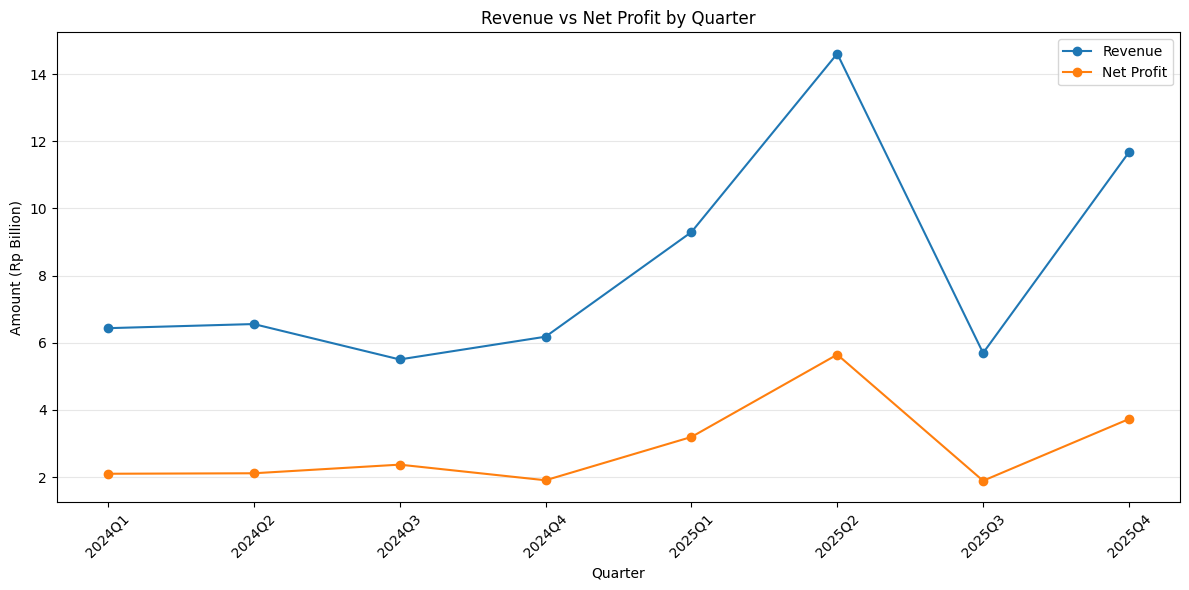

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(
    quarterly["quarter"],
    quarterly["revenue"] / 1e9,
    marker="o",
    label="Revenue"
)

plt.plot(
    quarterly["quarter"],
    quarterly["net_profit"] / 1e9,
    marker="o",
    label="Net Profit"
)

plt.title("Revenue vs Net Profit by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Amount (Rp Billion)")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The chart shows a significant decline in both revenue and net profit in Q3 2025. Revenue fell by approximately 61.01%, while net profit declined by 66.53% compared with Q2 2025. The simultaneous decline indicates that the profitability deterioration was closely associated with a substantial reduction in business scale. Management should investigate the drivers of the revenue decline before attributing the problem primarily to costs or discounts.

## **Chart 2 — Net Profit Change by Quarter**


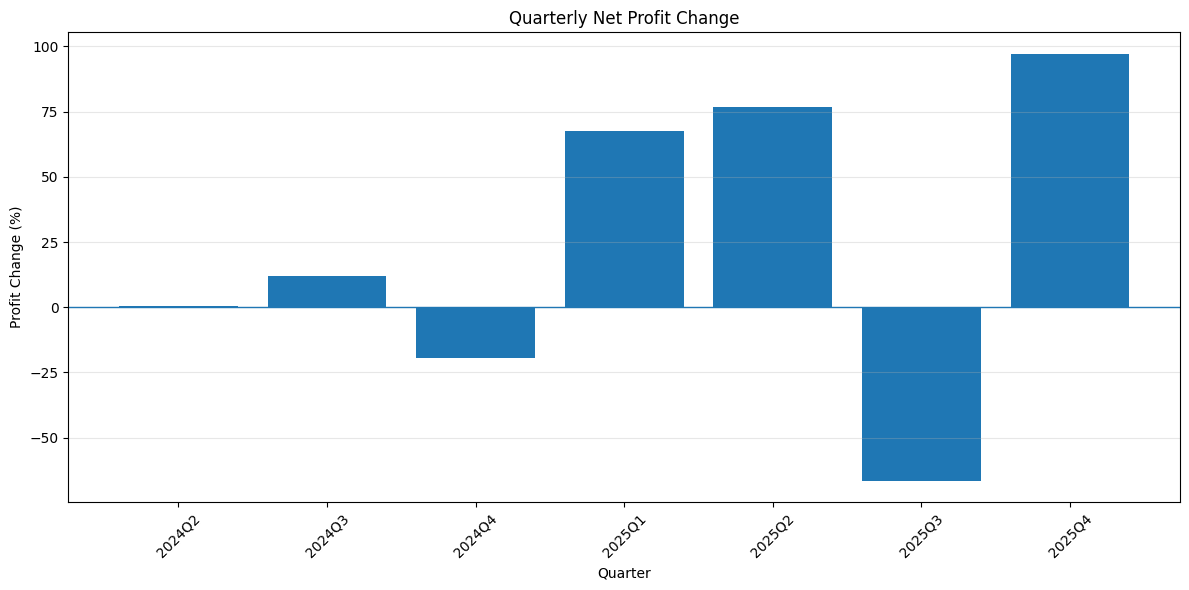

In [ ]:
plt.figure(figsize=(12, 6))
profit_change = quarterly.dropna(subset=["profit_change"])

plt.bar(
    profit_change["quarter"],
    profit_change["profit_change"]
)

plt.axhline(0, linewidth=1)
plt.title("Quarterly Net Profit Change")
plt.xlabel("Quarter")
plt.ylabel("Profit Change (%)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

This chart clearly shows:

1. 2024Q4 → -19.64%
2. 2025Q3 → -66.53%

The chart shows that Q3 2025 recorded the largest quarterly decline in net profit, falling by 66.53% compared with Q2 2025 — substantially larger than the only other negative quarter, Q4 2024 (-19.64%). Q3 2025 therefore represents the key period for investigating the drivers of the profitability deterioration.

## **Chart 3 — Profit Decline by Category**


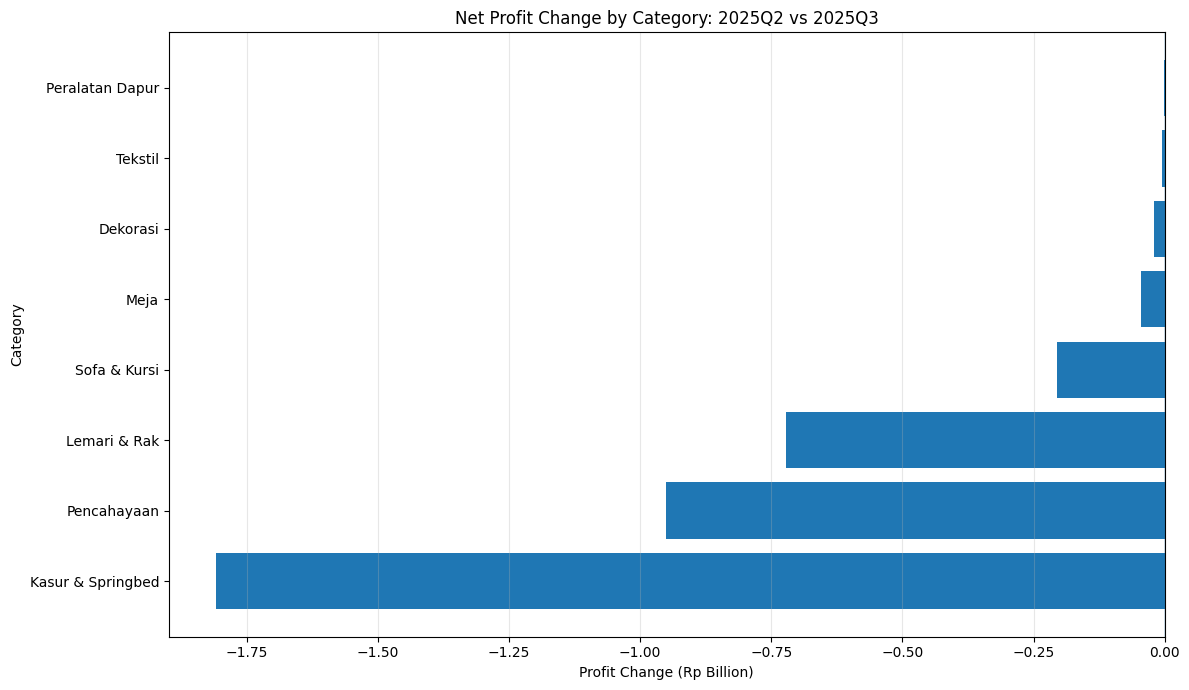

In [ ]:
plt.figure(figsize=(12, 7))

category_chart = category_pivot.sort_values("profit_change")

plt.barh(
    category_chart["category"],
    category_chart["profit_change"] / 1e9
)

plt.axvline(0, linewidth=1)
plt.title("Net Profit Change by Category: 2025Q2 vs 2025Q3")
plt.xlabel("Profit Change (Rp Billion)")
plt.ylabel("Category")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

This clearly shows:

1. Kasur & Springbed → -Rp1.81B (48.11%)
2. Pencahayaan → -Rp951M (25.30%)
3. Lemari & Rak → -Rp722M (19.21%)

Kasur & Springbed, Pencahayaan, and Lemari & Rak accounted for approximately 92.62% of the aggregate category-level profit decline. This indicates that the profitability deterioration was highly concentrated in these three categories rather than evenly distributed across the product portfolio. Management should therefore prioritize these categories for further investigation, particularly their pricing, product mix, cost structure, and promotional strategy.

## **Chart 4 — Online Profit Margin by Quarter**

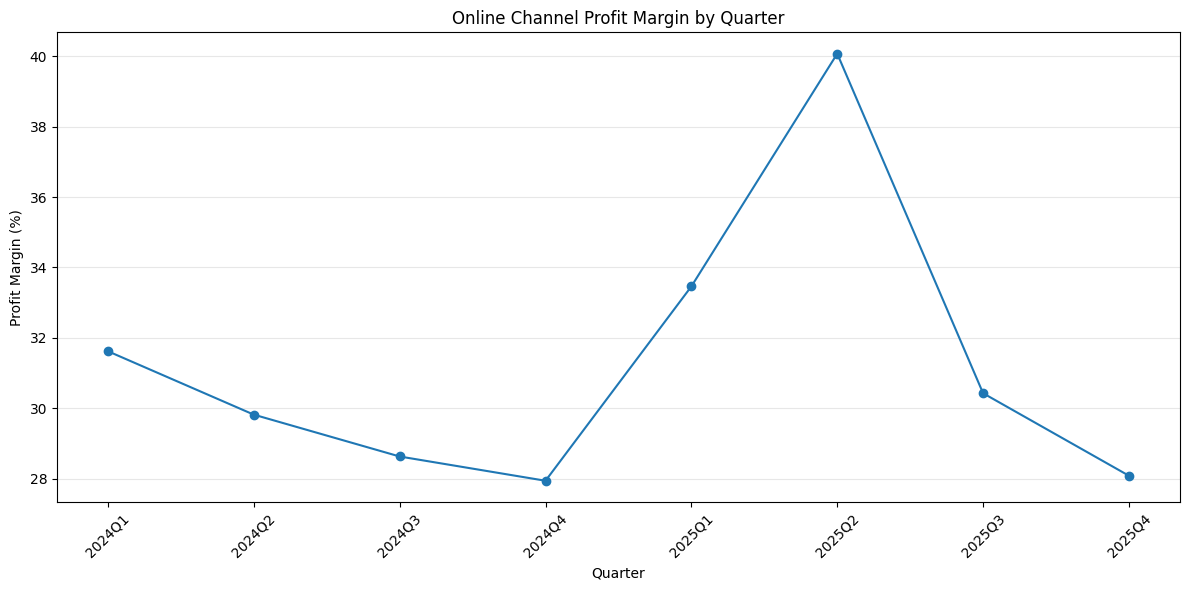

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    online_analysis["quarter"],
    online_analysis["profit_margin"],
    marker="o"
)

plt.title("Online Channel Profit Margin by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

This chart shows that the Online segment remains profitable, but:

1. 2025Q2 → 40.07%
2. 2025Q3 → 30.42%

The Online channel remained profitable, but its profit margin declined from 40.07% to 30.42%. This represents a decline of approximately 9.65 percentage points. Therefore, the appropriate strategy is not to eliminate Online sales, but to identify the specific components driving the margin deterioration, particularly shipping costs, discounts, product mix, and transaction-level profitability.

## **Chart 5 — Average Discount vs Profit Margin by Quarter**

Objective: To examine the relationship between average discount and profit margin over time.

,quarter,avg_discount,revenue,net_profit,profit_margin
0,2024Q1,9.080407,6.434633e+09,2.099136e+09,32.622467
1,2024Q2,8.776306,6.557338e+09,2.113285e+09,32.227788
2,2024Q3,8.574903,5.503120e+09,2.370312e+09,43.072148
3,2024Q4,15.071531,6.180556e+09,1.904868e+09,30.820340
4,2025Q1,8.274576,9.295288e+09,3.193960e+09,34.361064
5,2025Q2,8.047709,1.460922e+10,5.647917e+09,38.659937
6,2025Q3,8.788599,5.695672e+09,1.890390e+09,33.189935
7,2025Q4,20.375483,1.167405e+10,3.728539e+09,31.938685


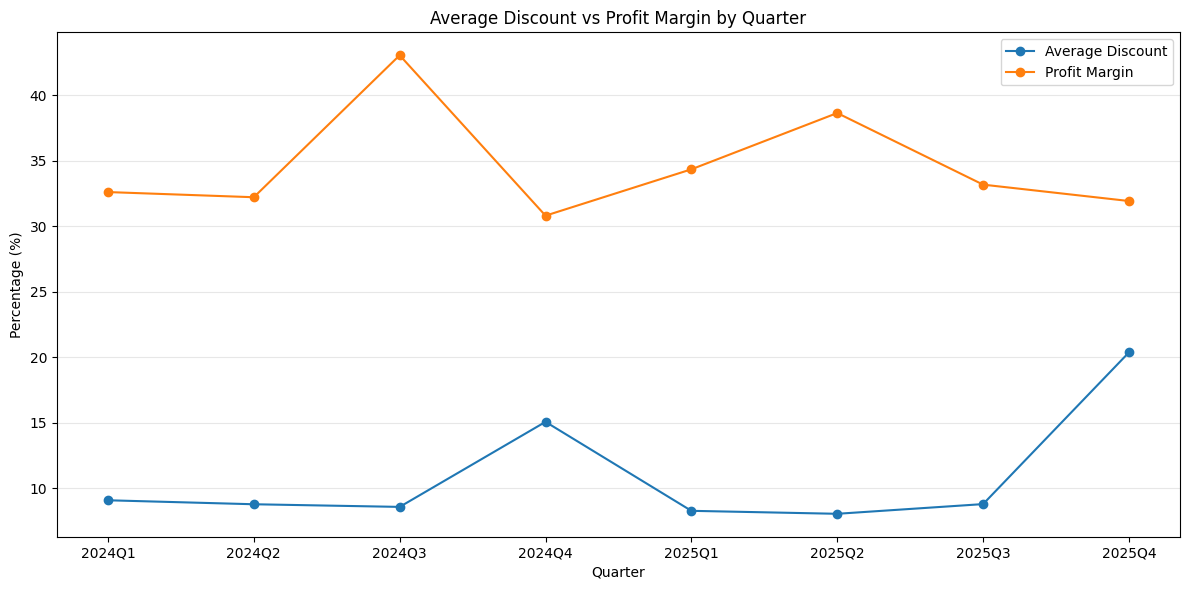

In [ ]:
discount_margin = (
    transaction_sales
    .groupby("quarter")
    .agg(
        avg_discount=("discount_pct", "mean"),
        revenue=("revenue", "sum"),
        net_profit=("net_profit", "sum")
    )
    .reset_index()
)

discount_margin["profit_margin"] = (
    discount_margin["net_profit"] /
    discount_margin["revenue"] * 100
)

display(discount_margin)


plt.figure(figsize=(12, 6))
plt.plot(
    discount_margin["quarter"],
    discount_margin["avg_discount"],
    marker="o",
    label="Average Discount"
)

plt.plot(
    discount_margin["quarter"],
    discount_margin["profit_margin"],
    marker="o",
    label="Profit Margin"
)

plt.title("Average Discount vs Profit Margin by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Percentage (%)")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Average discount increased by 0.74 percentage points from Q2 to Q3 2025, while profit margin decreased by 5.47 percentage points. This indicates potential margin pressure from increased discounting. However, discounting cannot be considered the primary cause based on this analysis alone because revenue contraction was substantially larger and appears to be a major contributor to the decline in absolute profit.

# **LIMITATIONS**

- The dataset contains duplicate and ambiguous transaction records. 60 duplicate groups (120 rows) were identified, and ambiguous records were excluded from the base-case analysis to avoid overstating financial performance.
- The analysis covers only 2024–2025, limiting the ability to assess longer-term trends and seasonality.
- The analysis identifies relationships between discounts, revenue, costs, and profitability but does not establish causality.
- Several potentially important business drivers, such as marketing spend, inventory availability, and competitor pricing, are not available in the dataset.
- Therefore, the findings should be treated as analytical evidence for further investigation rather than definitive explanations of the business performance decline.
- Order transactions with status "Dibatalkan" (cancelled) or "Retur"
(returned) were excluded from the base-case analysis (1,007 rows, 8.43% of the analysis dataset) because they do not represent realized sales.
- The channel labels "Toko Fisik" and "Offline" were found to refer to the same physical-store channel (verified via store_id) and were merged.
- A non-trivial share of fields required imputation before analysis: cost_price (8%), discount_pct (7%), shipping_cost (5%), and unit_price (9%). While each was imputed using a documented business rule, this remains an approximation of the true underlying values.

# **CONCLUSION**
The analysis identified Q3 2025 as the critical period for profitability deterioration, with net profit declining by 66.53% compared with Q2 2025. This decline was accompanied by an approximately 61.01% reduction in revenue and a 5.47 percentage-point decrease in profit margin, indicating that the deterioration was driven by both a substantial contraction in business scale and margin compression.


The profit decline was highly concentrated across categories, with Kasur & Springbed, Pencahayaan, and Lemari & Rak accounting for approximately 92.62% of the aggregate category-level profit decline. The Online channel remained profitable after accounting for shipping costs although its margin declined from 40.07% to 30.42%. Meanwhile, average discount increased from 8.05% to 8.79% (+0.74pp), suggesting mild margin pressure, but the available analysis does not establish discounting as the primary cause of the decline.


Overall, the findings suggest that management should prioritize the three most affected categories, investigate the drivers of Online margin deterioration, and apply targeted pricing and promotional strategies rather than broadly reducing discounts or Online sales volume.

# **EXPORT FOR BIGQUERY**

In [ ]:
# Export dataset untuk BigQuery
transaction_sales.to_csv("transaction_sales.csv",index=False)

print("File created successfully: transaction_sales.csv")
print("Rows:", len(transaction_sales))
print("Columns:", len(transaction_sales.columns))

from google.colab import files

files.download('transaction_sales.csv')

File created successfully: transaction_sales.csv
Rows: 10933
Columns: 26


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>